## Librerias


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import t as t_dist
import warnings

In [2]:
!pip install scipy

In [3]:
warnings.filterwarnings("ignore")

In [4]:
MATERIALES = {
    "Aluminio": {"archivo": "al.csv", "masa_g": 19.0},
    "Laton"   : {"archivo": "la.csv", "masa_g": 52.3},
    "Hierro"  : {"archivo": "fe.csv", "masa_g": 33.5},
}
 
CALIBRACION = {
    "archivo": "la.csv",
    "masa_g" : 80.0,
    "Cp_ref" : 0.380,    # J/(g·K) — latón
    "nombre" : "Laton",
}
 
CP_REFERENCIA = {
    "Aluminio": 0.897,
    "Laton"   : 0.380,
    "Hierro"  : 0.449,
}
 
CONFIANZA = 0.95

In [5]:
def modelo_newton(t, T_amb, T0, k): 
    
    return T_amb+(T0-T_amb)*np.exp(-k*t)
def cargar_csv(archivo):
    df=pd.read_csv(archivo)
    df.columns=df.columns.str.strip()
    df=df.dropna()
    return df["tiempo_ms"].values/1000.0, df["T_celsius"].values

In [6]:
def ajustar_exponencial(tiempo_s, temp):
    T_fin  = temp[-1]
    T_ini  = temp[0]
    p0     = [T_fin, T_ini, 0.01]
    bounds = ([T_fin - 15, T_ini - 15, 1e-6],
              [T_fin + 15, T_ini + 15, 10.0])
 
    popt, pcov = curve_fit(
        modelo_newton, tiempo_s, temp,
        p0=p0, bounds=bounds, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))
    dof  = len(tiempo_s) - 3
    t_c  = t_dist.ppf(1 - (1 - CONFIANZA) / 2, dof)
    ci   = t_c * perr
    return popt, perr, ci, dof

In [7]:
def estadisticos(tiempo_s, temp, popt):
    T_pred = modelo_newton(tiempo_s, *popt)
    RSS    = np.sum((temp - T_pred)**2)
    TSS    = np.sum((temp - temp.mean())**2)
    return 1 - RSS / TSS, np.sqrt(RSS / len(temp)), RSS / (len(temp) - 3)

In [8]:
def calibrar(cfg):
    print("=" * 65)
    print("  FASE 1 — CALIBRACIÓN DEL CALORÍMETRO")
    print("=" * 65)
    print(f"  Referencia : {cfg['nombre']}  |  masa: {cfg['masa_g']} g  |  Cp_ref: {cfg['Cp_ref']} J/(g·K)")
 
    tiempo_s, temp = cargar_csv(cfg["archivo"])
    popt, perr, ci, dof = ajustar_exponencial(tiempo_s, temp)
    R2, RMSE, chi2_r    = estadisticos(tiempo_s, temp, popt)
 
    k_ref     = popt[2]
    k_ref_err = ci[2]
 
    m   = cfg["masa_g"]
    Cp  = cfg["Cp_ref"]
 
    # Con C_cal = 0: hA = k * m * Cp  (límite inferior de hA)
    C_cal     = 0.0
    C_cal_err = 0.0
    hA        = k_ref * (m * Cp + C_cal)
    hA_err    = k_ref_err * (m * Cp + C_cal)   # dHA/dk * dk
 
    print(f"\n  k_ref = {k_ref:.6f} ± {k_ref_err:.6f} s⁻¹  (IC {CONFIANZA*100:.0f}%)")
    print(f"  R²    = {R2:.6f}  |  RMSE = {RMSE:.4f} °C  |  χ²ᵣ = {chi2_r:.4f}")
    print(f"\n  hA    = {hA:.6f} ± {hA_err:.6f} J/(s·K)  [con C_cal = 0]")
    print(f"\n  NOTA: C_cal fijado en 0 (un solo experimento de referencia).")
    print(f"  Para separar hA y C_cal exactamente, ver bloque 2x2 al final.")
 
    return hA, hA_err, C_cal, C_cal_err

In [9]:
def analizar_material(nombre, cfg_mat, hA, hA_err, C_cal, C_cal_err):
    tiempo_s, temp      = cargar_csv(cfg_mat["archivo"])
    m                   = cfg_mat["masa_g"]
    popt, _, ci, dof    = ajustar_exponencial(tiempo_s, temp)
    R2, RMSE, chi2_r    = estadisticos(tiempo_s, temp, popt)
 
    T_amb, T0, k = popt
    k_err        = ci[2]
 
    # Cp y propagación de error completa
    Cp = (hA / k - C_cal) / m
 
    dCp_dhA   =  1.0 / (m * k)
    dCp_dk    = -hA  / (m * k**2)
    dCp_dCcal = -1.0 / m
 
    Cp_err = np.sqrt(
        (dCp_dhA   * hA_err  )**2 +
        (dCp_dk    * k_err   )**2 +
        (dCp_dCcal * C_cal_err)**2
    )
 
    return {
        "nombre" : nombre,
        "masa_g" : m,
        "T_amb"  : round(T_amb,    3),
        "T0"     : round(T0,       3),
        "k"      : round(k,        6),
        "k_err"  : round(k_err,    6),
        "R2"     : round(R2,       6),
        "RMSE"   : round(RMSE,     4),
        "chi2_r" : round(chi2_r,   4),
        "dof"    : dof,
        "Cp"     : round(Cp,       4),
        "Cp_err" : round(Cp_err,   4),
    }

In [10]:
if __name__ == "__main__":
 
    hA, hA_err, C_cal, C_cal_err = calibrar(CALIBRACION)
 
    print(f"\n{'='*65}")
    print("  FASE 2 — ANÁLISIS DE MATERIALES")
    print(f"{'='*65}")
 
    resultados = []
 
    for nombre, cfg in MATERIALES.items():
        res = analizar_material(nombre, cfg, hA, hA_err, C_cal, C_cal_err)
        resultados.append(res)
 
        Cp_ref_val   = CP_REFERENCIA.get(nombre)
        discrepancia = abs(res["Cp"] - Cp_ref_val) / Cp_ref_val * 100 if Cp_ref_val else float("nan")
        sigma_n      = abs(res["Cp"] - Cp_ref_val) / res["Cp_err"] if (Cp_ref_val and res["Cp_err"] > 0) else float("nan")
 
        print(f"\n  {'─'*60}")
        print(f"  {nombre}  |  masa: {res['masa_g']} g")
        print(f"  {'─'*60}")
        print(f"    T_amb = {res['T_amb']:.3f} °C   T0 = {res['T0']:.3f} °C")
        print(f"    k     = {res['k']:.6f} ± {res['k_err']:.6f} s⁻¹")
        print(f"    R²    = {res['R2']:.6f}  |  RMSE = {res['RMSE']:.4f} °C  |  χ²ᵣ = {res['chi2_r']:.4f}")
        print(f"\n    Cp = {res['Cp']:.4f} ± {res['Cp_err']:.4f}  J/(g·K)  (IC {CONFIANZA*100:.0f}%)")
        if Cp_ref_val:
            print(f"    Cp tablas      = {Cp_ref_val:.4f} J/(g·K)")
            print(f"    Discrepancia   = {discrepancia:.2f}%   ({sigma_n:.2f} σ)")
 
    print(f"\n{'='*65}")
    print("  RESUMEN")
    print(f"{'='*65}")
    df_res = pd.DataFrame(resultados)
    df_res["Cp_ref"] = df_res["nombre"].map(CP_REFERENCIA)
    df_res["disc_%"] = ((df_res["Cp"] - df_res["Cp_ref"]).abs() / df_res["Cp_ref"] * 100).round(2)
    print(df_res[["nombre","k","k_err","R2","Cp","Cp_err","Cp_ref","disc_%"]].to_string(index=False))
 
    df_res.to_csv("resultados_calorimetro.csv", index=False)
    print("\n  Guardado en: resultados_calorimetro.csv")

  FASE 1 — CALIBRACIÓN DEL CALORÍMETRO
  Referencia : Laton  |  masa: 80.0 g  |  Cp_ref: 0.38 J/(g·K)

  k_ref = 0.104798 ± 0.002207 s⁻¹  (IC 95%)
  R²    = 0.998486  |  RMSE = 0.1784 °C  |  χ²ᵣ = 0.0333

  hA    = 3.185870 ± 0.067090 J/(s·K)  [con C_cal = 0]

  NOTA: C_cal fijado en 0 (un solo experimento de referencia).
  Para separar hA y C_cal exactamente, ver bloque 2x2 al final.

  FASE 2 — ANÁLISIS DE MATERIALES

  ────────────────────────────────────────────────────────────
  Aluminio  |  masa: 19.0 g
  ────────────────────────────────────────────────────────────
    T_amb = 8.060 °C   T0 = 87.760 °C
    k     = 0.002909 ± 0.091361 s⁻¹
    R²    = 0.241399  |  RMSE = 13.6812 °C  |  χ²ᵣ = 192.9061

    Cp = 57.6410 ± 1810.3053  J/(g·K)  (IC 95%)
    Cp tablas      = 0.8970 J/(g·K)
    Discrepancia   = 6325.98%   (0.03 σ)

  ────────────────────────────────────────────────────────────
  Laton  |  masa: 52.3 g
  ────────────────────────────────────────────────────────────
    T_am

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =====================================================================
# 1. Parámetros Constantes del Experimento
# =====================================================================
m_c = 56.37         # Masa equivalente del calorímetro (g)
m_agua = 100.0      # Masa de agua inicial (g)
M_eq = m_c + m_agua # Masa térmica total del sistema receptor (156.37 g)

# La temperatura inicial del metal NO es lo que lee el sensor al principio,
# sino la temperatura del agua hirviendo donde estaba sumergido.
T_0_muestra = 91.8  # Temperatura de ebullición en Bogotá (°C)

# Diccionario con tus masas reales y nombres de archivo
muestras = {
    'Aluminio': {'archivo': 'al.csv', 'masa': 19.0},
    'Laton':    {'archivo': 'la.csv', 'masa': 52.3},
    'Hierro':   {'archivo': 'fe.csv', 'masa': 33.5}
}

resultados = {}

# =====================================================================
# 2. Procesamiento de Datos y Cálculo
# =====================================================================
for nombre, datos in muestras.items():
    if not os.path.exists(datos['archivo']):
        print(f"Advertencia: No se encontró el archivo {datos['archivo']}.")
        continue
        
    df = pd.read_csv(datos['archivo'])
    df['tiempo_s'] = df['tiempo_ms'] / 1000.0
    
    # DINÁMICO: T_0_agua se lee del primer instante del sensor para cada metal
    T_0_agua = df['T_celsius'].iloc[0]
    
    # ESTADO ESTACIONARIO: T_e se promedia de los últimos 20 segundos
    Te = df['T_celsius'].tail(20).mean()
    
    # ECUACIÓN DE MEZCLAS: cx = [M_eq * (Te - T_0_agua)] / [m_muestra * (T_0_muestra - Te)]
    numerador = M_eq * (Te - T_0_agua)
    denominador = datos['masa'] * (T_0_muestra - Te)
    c_x = numerador / denominador
    
    resultados[nombre] = {
        'T_0_agua': T_0_agua,
        'Te': Te,
        'cx': c_x
    }
    
    # =====================================================================
    # 3. Generación de Gráficas Individuales
    # =====================================================================
    plt.figure(figsize=(8, 5))
    plt.plot(df['tiempo_s'], df['T_celsius'], color='#2c3e50', linewidth=2, label=f'Curva de calentamiento')
    plt.axhline(y=Te, color='#e74c3c', linestyle='--', label=f'$T_e$ = {Te:.2f} °C')
    plt.axhline(y=T_0_agua, color='#3498db', linestyle=':', label=f'$T_0$ (Agua) = {T_0_agua:.2f} °C')
    
    plt.title(f'Evolución del Equilibrio Térmico - {nombre}', fontsize=14)
    plt.xlabel('Tiempo (s)', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Guardar figura sin sobreescribir ni mostrar en bucle masivo
    plt.savefig(f'equilibrio_{nombre.lower()}.png', dpi=300)
    plt.close()

# =====================================================================
# 4. Impresión de Resultados Formateados
# =====================================================================
print("-" * 65)
print(f"{'Material':<12} | {'T0_agua (°C)':<12} | {'Te (°C)':<10} | {'c_x (cal/g°C)':<15}")
print("-" * 65)
for m, r in resultados.items():
    print(f"{m:<12} | {r['T_0_agua']:<12.2f} | {r['Te']:<10.2f} | {r['cx']:.4f}")
print("-" * 65)

-----------------------------------------------------------------
Material     | T0_agua (°C) | Te (°C)    | c_x (cal/g°C)  
-----------------------------------------------------------------
Aluminio     | 72.76        | 23.27      | -5.9434
Laton        | 41.34        | 21.94      | -0.8303
Hierro       | 58.55        | 23.95      | -2.3804
-----------------------------------------------------------------


Masa equivalente del calorímetro:
  mc = (56.47 ± 3.59) g

Aluminio:
  Te = (23.66 ± 0.08) °C
  c  = (1.125 ± 0.036) cal/g°C
  Teórico = 0.215 cal/g°C  |  Diferencia = 423.3%

Hierro:
  Te = (24.20 ± 0.05) °C
  c  = (0.862 ± 0.025) cal/g°C
  Teórico = 0.11 cal/g°C  |  Diferencia = 683.9%

Latón:
  Te = (22.07 ± 0.05) °C
  c  = (0.241 ± 0.008) cal/g°C
  Teórico = 0.092 cal/g°C  |  Diferencia = 162.0%



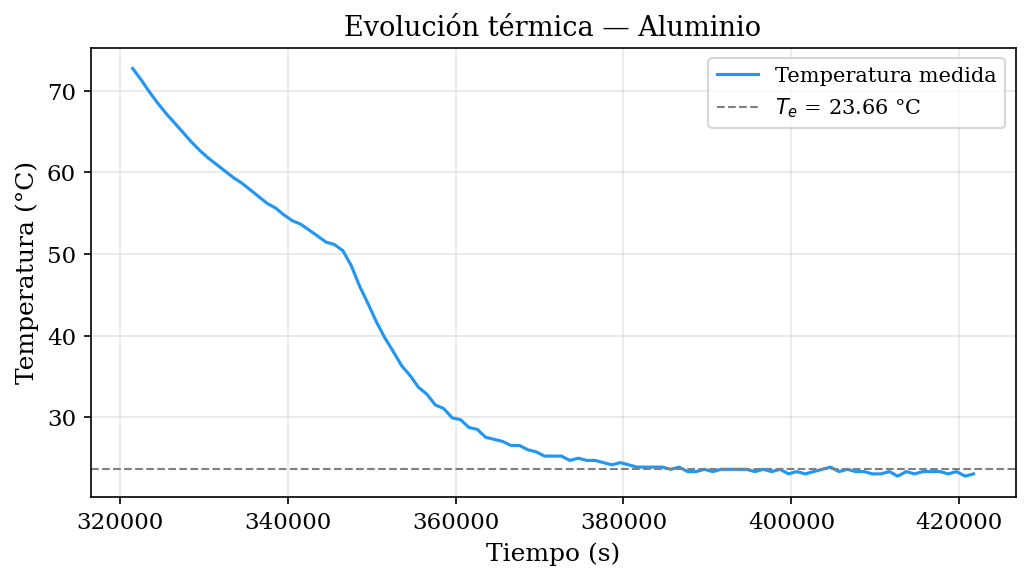

Guardada: figuras/temp_vs_tiempo_aluminio.png


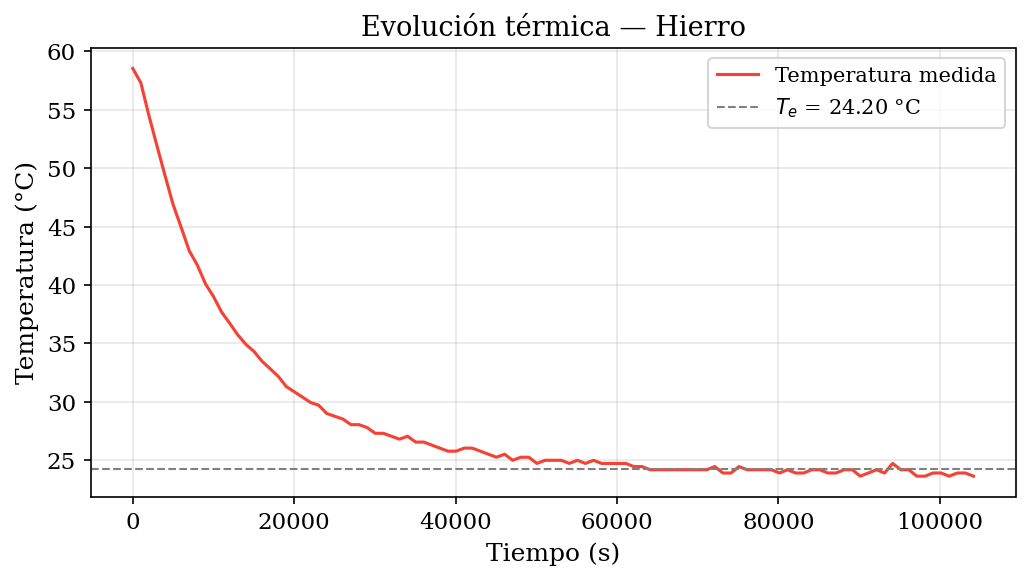

Guardada: figuras/temp_vs_tiempo_hierro.png


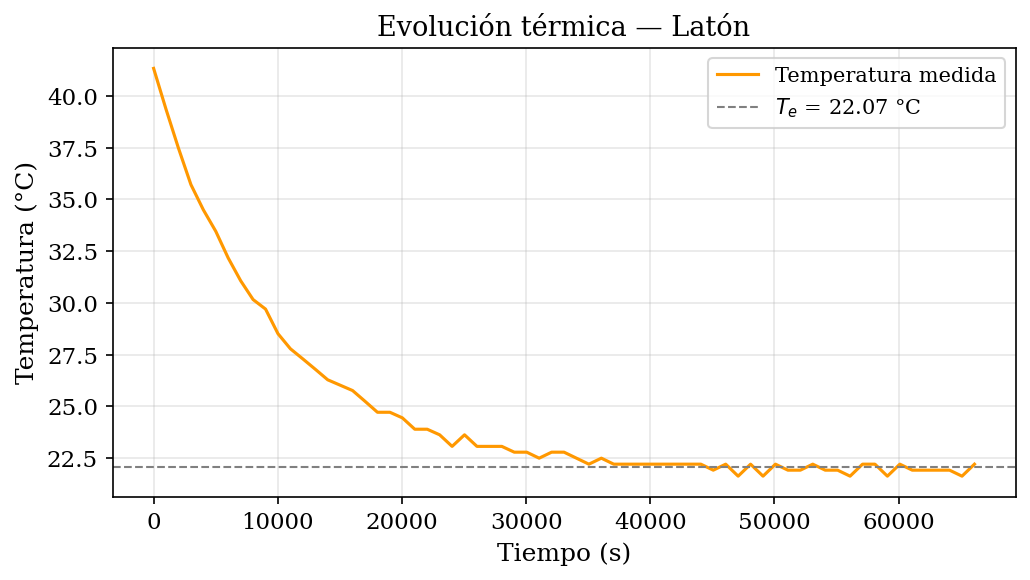

Guardada: figuras/temp_vs_tiempo_laton.png


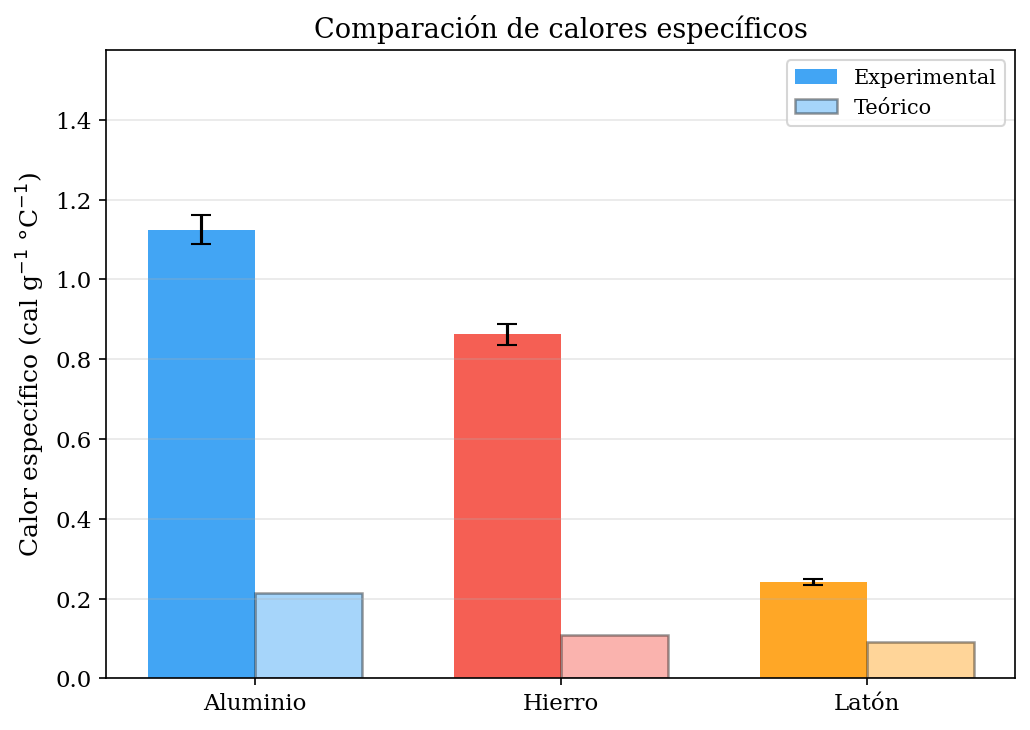

Guardada: figuras/comparacion_calores_especificos.png


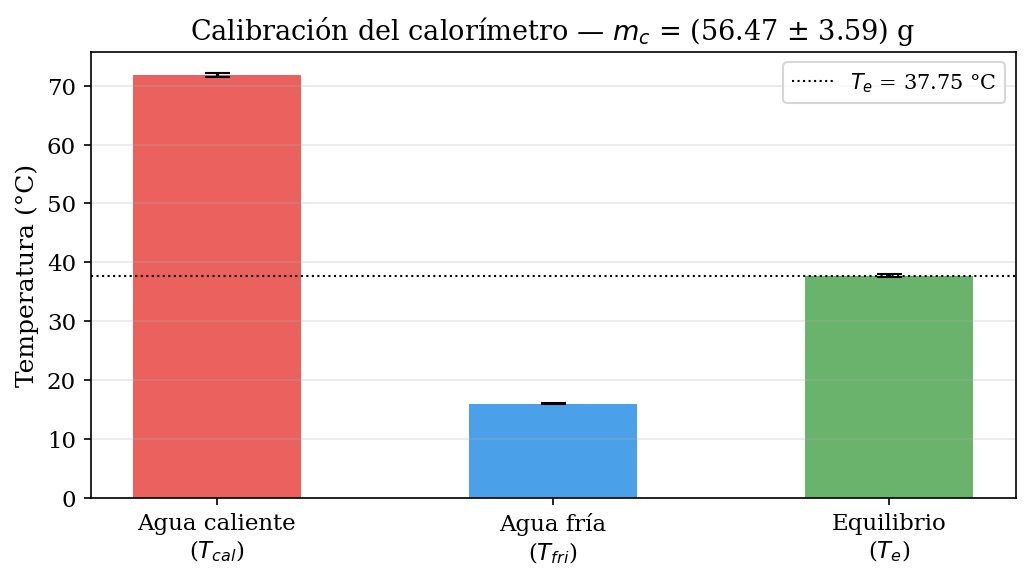

Guardada: figuras/calibracion_calorimetro.png


In [14]:
"""
Estimación de la capacidad calorífica por el método de mezclas
Baracaldo & Sarria — Termodinámica Módulo Experimental
--------------------------------------------------------------
Carga los CSV con columnas: tiempo_s, T_C
Si no hay CSV, usa los valores del informe como fallback.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ─────────────────────────────────────────────
# 0. CONFIGURACIÓN GENERAL DE GRÁFICAS
# ─────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "figure.dpi": 150,
})

SAVE_DIR = "figuras"
os.makedirs(SAVE_DIR, exist_ok=True)

# ─────────────────────────────────────────────
# 1. CARGA DE DATOS (CSV o fallback del informe)
# ─────────────────────────────────────────────

def cargar_csv(path):
    """Carga un CSV con columnas tiempo_s y T_C. Retorna DataFrame o None."""
    try:
        df = pd.read_csv(path)
        # Normalizar nombres de columna
        df.columns = [c.strip().lower() for c in df.columns]
        col_t = next((c for c in df.columns if "t_c" in c or "temp" in c or "t (c" in c), None)
        col_s = next((c for c in df.columns if "tiempo" in c or "time" in c or "t (s" in c), None)
        if col_t and col_s:
            df = df.rename(columns={col_s: "tiempo_s", col_t: "T_C"})
            return df[["tiempo_s", "T_C"]].dropna()
    except Exception:
        pass
    return None

al_df = cargar_csv("al.csv")
fe_df = cargar_csv("fe.csv")
la_df = cargar_csv("la.csv")

# Fallback: valores del informe (temperatura constante de equilibrio)
# Si no hay CSV, simulamos la serie temporal con los promedios del informe
def serie_fallback(T0, Te, N=120):
    """Aproximación exponencial de enfriamiento hacia Te."""
    tau = 30  # constante de tiempo ficticia en segundos
    t = np.arange(N)
    T = Te + (T0 - Te) * np.exp(-t / tau)
    return pd.DataFrame({"tiempo_s": t, "T_C": T})

DATOS = {
    "Aluminio": {
        "df": al_df if al_df is not None else serie_fallback(91.8, 17.62),
        "m1": 100.0, "sigma_m1": 0.1,
        "m2": 15.7,  "sigma_m2": 0.1,
        "T02": 91.8, "sigma_T02": 0.5,
        "T_ref": 0.215,   # cal/g°C teórico
        "color": "#2196F3",
        "label": "Aluminio",
    },
    "Hierro": {
        "df": fe_df if fe_df is not None else serie_fallback(91.8, 17.1),
        "m1": 100.0, "sigma_m1": 0.1,
        "m2": 22.1,  "sigma_m2": 0.1,
        "T02": 91.8, "sigma_T02": 0.5,
        "T_ref": 0.11,
        "color": "#F44336",
        "label": "Hierro",
    },
    "Laton": {
        "df": la_df if la_df is not None else serie_fallback(91.8, 16.6),
        "m1": 100.0, "sigma_m1": 0.1,
        "m2": 56.8,  "sigma_m2": 0.1,
        "T02": 91.8, "sigma_T02": 0.5,
        "T_ref": 0.092,
        "color": "#FF9800",
        "label": "Latón",
    },
}

# Calibración del calorímetro (datos del informe)
CAL = {
    "mcal": 100.0, "sigma_mcal": 0.1,
    "mfri": 100.0, "sigma_mfri": 0.1,
    "Tcal": 71.83, "sigma_Tcal": 0.31,
    "Tfri": 15.97, "sigma_Tfri": 0.12,
    "Te":   37.75, "sigma_Te":   0.27,
}

# T01 compartida (temperatura ambiente inicial del agua en el calorímetro)
T01       = 15.97
sigma_T01 = 0.12

# ─────────────────────────────────────────────
# 2. FUNCIONES DE CÁLCULO
# ─────────────────────────────────────────────

def promedio_equilibrio(df, fraccion_final=0.5):
    """
    Promedia la fracción final de la serie temporal (zona de equilibrio).
    Retorna (Te, sigma_Te).
    """
    n = len(df)
    inicio = int(n * (1 - fraccion_final))
    zona = df["T_C"].iloc[inicio:]
    Te = zona.mean()
    sigma_Te = zona.std(ddof=1) / np.sqrt(len(zona))
    return Te, sigma_Te


def masa_equivalente(cal):
    """Calcula mc y su incertidumbre por propagación."""
    mcal, mfri = cal["mcal"], cal["mfri"]
    Tcal, Tfri, Te = cal["Tcal"], cal["Tfri"], cal["Te"]

    mc = mcal * (Tcal - Te) / (Te - Tfri) - mfri

    # Derivadas parciales
    denom = (Te - Tfri)
    dmc_dmcal = (Tcal - Te) / denom
    dmc_dmfri = -1.0
    dmc_dTcal = mcal / denom
    dmc_dTfri = mcal * (Tcal - Te) / denom**2
    dmc_dTe   = (-mcal * denom - mcal * (Tcal - Te)) / denom**2

    sigma_mc = np.sqrt(
        (dmc_dmcal * cal["sigma_mcal"])**2 +
        (dmc_dmfri * cal["sigma_mfri"])**2 +
        (dmc_dTcal * cal["sigma_Tcal"])**2 +
        (dmc_dTfri * cal["sigma_Tfri"])**2 +
        (dmc_dTe   * cal["sigma_Te"])**2
    )
    return mc, sigma_mc


def calor_especifico(mc, sigma_mc, m1, sigma_m1, m2, sigma_m2,
                     T01, sigma_T01, T02, sigma_T02, Te, sigma_Te):
    """
    Ecuación (6) del informe:
        c2 = (mc + m1)(Te - T01) / [m2 (T02 - Te)]
    Propagación de incertidumbre por derivadas parciales.
    """
    num = (mc + m1) * (Te - T01)
    den = m2 * (T02 - Te)
    c2 = num / den

    # Derivadas parciales
    dc_dmc  = (Te - T01) / den
    dc_dm1  = (Te - T01) / den
    dc_dm2  = -c2 / m2
    dc_dT01 = -(mc + m1) / den
    dc_dT02 = -c2 / (T02 - Te)
    dc_dTe  = (mc + m1) / den + c2 / (T02 - Te)

    sigma_c = np.sqrt(
        (dc_dmc  * sigma_mc )**2 +
        (dc_dm1  * sigma_m1 )**2 +
        (dc_dm2  * sigma_m2 )**2 +
        (dc_dT01 * sigma_T01)**2 +
        (dc_dT02 * sigma_T02)**2 +
        (dc_dTe  * sigma_Te )**2
    )
    return c2, sigma_c

# ─────────────────────────────────────────────
# 3. CÁLCULO PRINCIPAL
# ─────────────────────────────────────────────

# 3.1 Masa equivalente del calorímetro
mc, sigma_mc = masa_equivalente(CAL)
print(f"Masa equivalente del calorímetro:")
print(f"  mc = ({mc:.2f} ± {sigma_mc:.2f}) g\n")

# 3.2 Calor específico de cada muestra
resultados = {}

for nombre, d in DATOS.items():
    df = d["df"]

    # Temperatura de equilibrio desde CSV (o fallback)
    Te, sigma_Te = promedio_equilibrio(df)

    c2, sigma_c2 = calor_especifico(
        mc, sigma_mc,
        d["m1"], d["sigma_m1"],
        d["m2"], d["sigma_m2"],
        T01, sigma_T01,
        d["T02"], d["sigma_T02"],
        Te, sigma_Te,
    )

    error_pct = abs(c2 - d["T_ref"]) / d["T_ref"] * 100

    resultados[nombre] = {
        "Te": Te, "sigma_Te": sigma_Te,
        "c2": c2, "sigma_c2": sigma_c2,
        "T_ref": d["T_ref"],
        "error_pct": error_pct,
    }

    print(f"{d['label']}:")
    print(f"  Te = ({Te:.2f} ± {sigma_Te:.2f}) °C")
    print(f"  c  = ({c2:.3f} ± {sigma_c2:.3f}) cal/g°C")
    print(f"  Teórico = {d['T_ref']} cal/g°C  |  Diferencia = {error_pct:.1f}%\n")

# ─────────────────────────────────────────────
# 4. GRÁFICAS INDIVIDUALES — TEMPERATURA vs TIEMPO
# ─────────────────────────────────────────────

for nombre, d in DATOS.items():
    df = d["df"]
    res = resultados[nombre]
    Te = res["Te"]

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(df["tiempo_s"], df["T_C"],
            color=d["color"], linewidth=1.5, label="Temperatura medida")
    ax.axhline(Te, color="gray", linestyle="--", linewidth=1,
               label=f"$T_e$ = {Te:.2f} °C")

    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Temperatura (°C)")
    ax.set_title(f"Evolución térmica — {d['label']}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f"{SAVE_DIR}/temp_vs_tiempo_{nombre.lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Guardada: {fname}")

# ─────────────────────────────────────────────
# 5. GRÁFICA COMPARATIVA: exp vs teórico
# ─────────────────────────────────────────────

nombres_plot = [DATOS[k]["label"] for k in DATOS]
c_exp   = [resultados[k]["c2"]      for k in DATOS]
sigma_c = [resultados[k]["sigma_c2"] for k in DATOS]
c_teo   = [DATOS[k]["T_ref"]        for k in DATOS]
colores = [DATOS[k]["color"]         for k in DATOS]

x = np.arange(len(nombres_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))

bars1 = ax.bar(x - width/2, c_exp, width, yerr=sigma_c,
               capsize=5, color=colores, alpha=0.85, label="Experimental")
bars2 = ax.bar(x + width/2, c_teo, width,
               color=colores, alpha=0.4, edgecolor="black",
               linewidth=1.2, label="Teórico")

ax.set_xticks(x)
ax.set_xticklabels(nombres_plot)
ax.set_ylabel("Calor específico (cal g$^{-1}$ °C$^{-1}$)")
ax.set_title("Comparación de calores específicos")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(c_exp + c_teo) * 1.4)

plt.tight_layout()
fname_comp = f"{SAVE_DIR}/comparacion_calores_especificos.png"
plt.savefig(fname_comp, dpi=150)
plt.show()
print(f"Guardada: {fname_comp}")

# ─────────────────────────────────────────────
# 6. GRÁFICA DE CALIBRACIÓN
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))

# Diagrama esquemático del balance de calibración
labels_cal = ["Agua caliente\n($T_{cal}$)", "Agua fría\n($T_{fri}$)", "Equilibrio\n($T_e$)"]
temps_cal  = [CAL["Tcal"], CAL["Tfri"], CAL["Te"]]
errs_cal   = [CAL["sigma_Tcal"], CAL["sigma_Tfri"], CAL["sigma_Te"]]
col_cal    = ["#E53935", "#1E88E5", "#43A047"]

ax.bar(labels_cal, temps_cal, yerr=errs_cal, capsize=6,
       color=col_cal, alpha=0.8, width=0.5)
ax.axhline(CAL["Te"], color="black", linestyle=":", linewidth=1, label=f"$T_e$ = {CAL['Te']} °C")
ax.set_ylabel("Temperatura (°C)")
ax.set_title(f"Calibración del calorímetro — $m_c$ = ({mc:.2f} ± {sigma_mc:.2f}) g")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fname_cal = f"{SAVE_DIR}/calibracion_calorimetro.png"
plt.savefig(fname_cal, dpi=150)
plt.show()
print(f"Guardada: {fname_cal}")